# Cue-Centered Lag-Rank Analysis

> Temporal factor score from external retrieval cue to recalled item.

The cue-centered lag-rank analysis measures temporal organization from an
external retrieval cue to the recalled item. It parallels `cue_centered_crp`
but produces a scalar factor per trial instead of a CRP curve.
A score of 0.5 indicates chance; scores above 0.5 reflect temporal contiguity
between the cue and the recalled item.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `trial_query` | Query selecting trials to analyze |
| `size` | Max study positions an item can occupy |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.cue_centered_lagrank import (
    cue_centered_lagrank,
    plot_cue_centered_lagrank,
    subject_cue_centered_lagrank,
    test_cue_centered_lagrank,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.selective_interference import derive_cue_clips

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = ""
trial_query = None
size = 1

In [4]:
#| code-summary: Load data and derive cue attributions
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

# Derive cue_clips from the interleaved event sequence
cue_clips = derive_cue_clips(
    np.array(data["recall_items"]),
    np.array(data["recall_types"]),
    np.array(data["recalls"]),
)
data["cue_clips"] = jnp.array(cue_clips)
data["_should_tabulate"] = data["recalls"] > 0

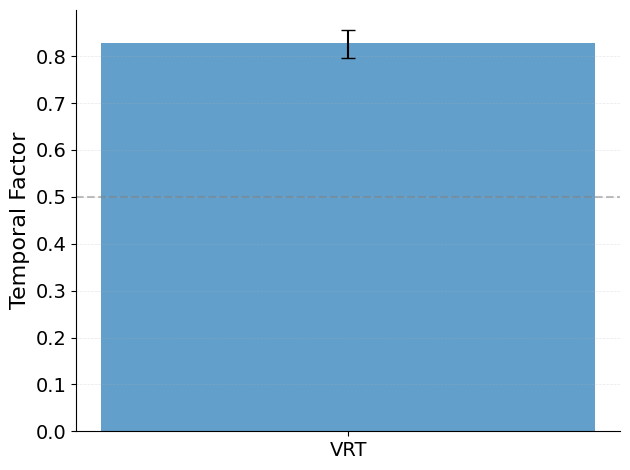

In [5]:
#| code-summary: Plot cue-centered lag-rank factor
#| label: fig-cue-centered-lagrank
#| fig-cap: "Cue-centered temporal factor score. Dashed line indicates chance (0.5)."
plot_cue_centered_lagrank(
    data, trial_mask,
    should_tabulate=data["_should_tabulate"],
    size=size,
    labels=["VRT"],
)
save_figure(figure_dir, figure_str)

## Summary

In [6]:
#| code-summary: Cue-centered temporal factor statistics
factors = subject_cue_centered_lagrank(data, trial_mask, size=size)
result = test_cue_centered_lagrank(factors)

print()
print("=" * 60)
print("Cue-Centered Temporal Factor")
print("=" * 60)
print(result)


Cue-Centered Temporal Factor
N=227
Mean factor: 0.8289
t-stat: 21.752 p=0.0000
W-stat: 987.0 p=0.0000


---

## Reference

In [7]:
#| echo: false
show_doc(cue_centered_lagrank)

---

### cue_centered_lagrank

>      cue_centered_lagrank (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Compute per-trial cue-centered lag-rank factor.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls``, ``pres_itemnos``,<br>``cue_clips``, and ``_should_tabulate``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'trials']** |  | **Temporal factor per trial; NaN where no transitions qualify.** |

In [8]:
#| echo: false
show_doc(subject_cue_centered_lagrank)

---

### subject_cue_centered_lagrank

>      subject_cue_centered_lagrank (dataset:jaxcmr.typing.RecallDataset,
>                                    trial_mask:jaxtyping.Bool[Array,'trial_coun
>                                    t'], size:int=3)

*Compute per-subject mean cue-centered lag-rank factor.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls``, ``pres_itemnos``,<br>``cue_clips``, and ``_should_tabulate``. |
| trial_mask | Bool[Array, 'trial_count'] |  | Boolean mask selecting trials. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **ndarray** |  | **Shape ``(n_subjects,)``.** |

In [9]:
#| echo: false
show_doc(plot_cue_centered_lagrank)

---

### plot_cue_centered_lagrank

>      plot_cue_centered_lagrank (datasets:Union[Sequence[jaxcmr.typing.RecallDa
>                                 taset],jaxcmr.typing.RecallDataset], trial_mas
>                                 ks:Union[Sequence[jaxtyping.Bool[Array,'trial_
>                                 count']],jaxtyping.Bool[Array,'trial_count']],
>                                 should_tabulate:Union[Sequence[jaxtyping.Bool[
>                                 Array,'trial_countrecall_events']],jaxtyping.B
>                                 ool[Array,'trial_countrecall_events']],
>                                 size:int=3,
>                                 color_cycle:Optional[list[str]]=None,
>                                 labels:Optional[Sequence[str]]=None,
>                                 contrast_name:Optional[str]=None, axis:Optiona
>                                 l[matplotlib.axes._axes.Axes]=None,
>                                 confidence_level:float=0.95)

*Plot cue-centered lag-rank factors as a bar chart.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | One or more datasets to plot. |
| trial_masks | Union |  | Boolean mask(s) selecting trials. |
| should_tabulate | Union |  | Boolean masks aligned to recall events. |
| size | int | 3 | Max study positions an item can occupy. |
| color_cycle | Optional | None | Colors for each bar. |
| labels | Optional | None | Labels for each dataset. |
| contrast_name | Optional | None | Legend title. |
| axis | Optional | None | Existing Axes to plot on. |
| confidence_level | float | 0.95 | Confidence level for error bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with the bar chart.** |

In [10]:
# Cue-centered temporal factor should exceed chance
assert np.nanmean(factors) > 0.5, "Mean factor should exceed chance (0.5)"
assert result.t_pval < 0.05, "Factor should be significantly above chance"